# Forest-Fire Susceptibility — Validation Against 2026 Fire Hotspots

**Idea:** the models were trained on fire labels built from **2015–2025** FIRMS
hotspots only. The **2026** hotspots were *never seen* during training, so they
form a genuine held-out future set. Here we reload the saved models, score every
flammable cell, and test the core claim:

> *Did the cells the model rated **high-susceptibility** actually burn in 2026?*

This notebook is **self-contained** — it redefines its constants inline and does
**not** import the `scripts/` data-download package.

In [1]:
import os
# macOS: torch, xgboost and lightgbm each bundle their own OpenMP (libomp).
# Loading/predicting with all of them in one process otherwise SEGFAULTS the
# kernel (no Python traceback). Two defenses, both required, both set/done
# BEFORE importing torch:
#   1. tolerate the duplicate runtime + single-thread it
#   2. import the tree libs first so their libomp loads before torch's
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import lightgbm        # noqa: F401  (pre-load OpenMP before torch)
import xgboost         # noqa: F401

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT           = Path(os.getcwd()).parent
DATA_PROCESSED = ROOT / "data" / "processed"
FIRMS_DIR      = ROOT / "data" / "raw" / "firms"
MODELS_DIR     = ROOT / "outputs" / "models"

# ── canonical 100 m grid (same values the training notebooks use) ──
STUDY_AREA = {"lat_min": 27.00, "lat_max": 28.40,
              "lon_min": 84.00, "lon_max": 86.60, "crs": "EPSG:4326"}
RES = 3.0 / 3600.0
LON_MIN, LON_MAX = STUDY_AREA["lon_min"], STUDY_AREA["lon_max"]
LAT_MIN, LAT_MAX = STUDY_AREA["lat_min"], STUDY_AREA["lat_max"]
W = int(round((LON_MAX - LON_MIN) / RES))
H = int(round((LAT_MAX - LAT_MIN) / RES))

def canonical_grid():
    from rasterio.transform import from_origin
    return from_origin(LON_MIN, LAT_MAX, RES, RES), W, H, STUDY_AREA["crs"]

# ── the 26-feature set (identical order to both training notebooks) ──
TOPO    = ["elevation_m", "slope_deg", "aspect_sin", "aspect_cos", "tri", "twi", "solar_radiation"]
CLIMATE = ["temp_max_mean_c", "wind_max_mean_kmh", "precip_fire_season_mm",
           "drought_factor", "fwi_proxy", "consec_dry_days_max"]
VEG     = ["ndvi_fire_season", "ndvi_premonsoon", "ndvi_anomaly", "evi", "nbr",
           "ndwi", "lst_fire_season_mean_c"]
HUMAN   = ["log_dist_to_road", "log_dist_to_settlement", "log_dist_to_forest_edge",
           "log_dist_to_cropland", "log_population_density"]
LAND    = ["lulc_code"]
FEATURES = TOPO + CLIMATE + VEG + HUMAN + LAND
TARGET   = "fire_occurred"

DEVICE = torch.device("cpu")
print(f"grid {W} x {H} | {len(FEATURES)} features | models -> {MODELS_DIR}")

grid 3120 x 1680 | 26 features | models -> /Users/bikinshrestha/Personal/masters/data_analytics/sem_project/outputs/models


### The PyTorch architecture (redefined so we can reload its weights)
This must match `pytorch_train.ipynb` exactly — the saved file holds only the
`state_dict`, not the class.

In [2]:
class FireMLP(nn.Module):
    def __init__(self, n_features, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

## 1 · Load the flammable cells and map each to its grid pixel
We reproduce the exact filter/order the training notebooks used, then attach the
grid pixel for every cell with the **`np.round`** convention inference used — so a
2026 hotspot is attributed to the very cell whose susceptibility we scored.

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "forest_fire_dataset_100m.parquet")
df = df[df["is_flammable"] == 1].reset_index(drop=True)

df["col"] = np.clip(np.round((df["lon"].values - LON_MIN) / RES).astype(int), 0, W - 1)
df["row"] = np.clip(np.round((LAT_MAX - df["lat"].values) / RES).astype(int), 0, H - 1)
df["cell_id"] = df["row"].astype(np.int64) * W + df["col"].astype(np.int64)

print(f"flammable cells                  : {len(df):,}")
print(f"historical fire cells (2015-2025): {int(df[TARGET].sum()):,} ({df[TARGET].mean():.3%})")
df[["lat", "lon", TARGET]].head(3)

flammable cells                  : 2,123,648
historical fire cells (2015-2025): 4,131 (0.195%)


,lat,lon,fire_occurred
0,28.338750,85.206250,0.0
1,28.338750,85.207083,0.0
2,28.337917,85.207083,0.0


## 2 · Build the 2026 actual-burned label
**Headline = MODIS-only, confidence ≥ 50** (mirrors how the training labels were
built). **Sensitivity = all sensors** (MODIS + VIIRS SNPP + VIIRS NOAA-20); VIIRS
confidence is categorical so we keep `n` (nominal) and `h` (high), dropping `l`.

In [4]:
FIRMS_FILES = {
    "MODIS":        "firms_MODIS_SP_2026.csv",
    "VIIRS_SNPP":   "firms_VIIRS_SNPP_SP_2026.csv",
    "VIIRS_NOAA20": "firms_VIIRS_NOAA20_SP_2026.csv",
}

def load_2026_fires(sensors, min_modis_conf=50, viirs_keep=("n", "h")):
    frames = []
    for s in sensors:
        d = pd.read_csv(FIRMS_DIR / FIRMS_FILES[s], usecols=["lat", "lon", "confidence", "acq_date"])
        if s == "MODIS":
            d = d[pd.to_numeric(d["confidence"], errors="coerce") >= min_modis_conf]
        else:
            d = d[d["confidence"].astype(str).str.lower().isin(viirs_keep)]
        frames.append(d[["lat", "lon", "acq_date"]])
        print(f"  {s:13s}: {len(d):,} hotspots kept")
    return pd.concat(frames, ignore_index=True)

def burned_cell_ids(fires):
    lon, lat = fires["lon"].values, fires["lat"].values
    inb = (lon >= LON_MIN) & (lon <= LON_MAX) & (lat >= LAT_MIN) & (lat <= LAT_MAX)
    col = np.round((lon[inb] - LON_MIN) / RES).astype(np.int64)
    row = np.round((LAT_MAX - lat[inb]) / RES).astype(np.int64)
    return set((row * W + col).tolist())

print("MODIS-only:")
fires_modis = load_2026_fires(["MODIS"])
modis_cells = burned_cell_ids(fires_modis)
print("\nall sensors:")
fires_all = load_2026_fires(["MODIS", "VIIRS_SNPP", "VIIRS_NOAA20"])
all_cells = burned_cell_ids(fires_all)

flammable_ids = set(df["cell_id"].tolist())
df["burned_2026"]     = df["cell_id"].isin(modis_cells).astype(int)
df["burned_2026_all"] = df["cell_id"].isin(all_cells).astype(int)

print("\n2026 fire dates:", fires_all["acq_date"].min(), "->", fires_all["acq_date"].max(),
      "(partial year — pre-monsoon season runs Feb-May)")
for name, cells, col in [("MODIS-only", modis_cells, "burned_2026"),
                         ("all-sensors", all_cells, "burned_2026_all")]:
    on_flam = len(cells & flammable_ids)
    recur   = int(((df[col] == 1) & (df[TARGET] == 1)).sum())
    print(f"{name:12s}: {len(cells):,} burned grid cells | {on_flam:,} on flammable cells | "
          f"{int(df[col].sum()):,} flammable rows flagged | {recur:,} also burned 2015-2025")

MODIS-only:
  MODIS        : 100 hotspots kept

all sensors:
  MODIS        : 100 hotspots kept
  VIIRS_SNPP   : 1,127 hotspots kept
  VIIRS_NOAA20 : 1,202 hotspots kept

2026 fire dates: 2026-01-01 -> 2026-03-31 (partial year — pre-monsoon season runs Feb-May)
MODIS-only  : 100 burned grid cells | 20 on flammable cells | 25 flammable rows flagged | 9 also burned 2015-2025
all-sensors : 2,395 burned grid cells | 470 on flammable cells | 614 flammable rows flagged | 19 also burned 2015-2025


## 3 · Load the saved models
`sklearn_models.joblib` (all five estimators + imputer/scaler/thresholds/ranking/
Jenks breaks) and the PyTorch `state_dict` + its own preprocessing bundle.

In [5]:
bundle       = joblib.load(MODELS_DIR / "sklearn_models.joblib")
assert bundle["features"] == FEATURES, "feature-order drift vs training!"
sk_models    = bundle["models"]
model_kind   = bundle["model_kind"]
imputer      = bundle["imputer"]
scaler       = bundle["scaler"]
jenks_breaks = bundle["jenks_breaks"]
risk_labels  = bundle["risk_labels"]
best_sklearn = bundle["res_df"].index[0]
print("sklearn models :", list(sk_models), "| best on holdout:", best_sklearn)

pp = joblib.load(MODELS_DIR / "pytorch_mlp_preprocess.joblib")
assert pp["features"] == FEATURES
pt_model = FireMLP(pp.get("n_features", len(FEATURES))).to(DEVICE)
pt_model.load_state_dict(torch.load(MODELS_DIR / "pytorch_mlp_state.pt", map_location=DEVICE))
pt_model.eval()
print("pytorch MLP    : loaded (", sum(p.numel() for p in pt_model.parameters()), "params )")

sklearn models : ['LogisticReg', 'RandomForest', 'XGBoost', 'LightGBM', 'MLP'] | best on holdout: MLP
pytorch MLP    : loaded ( 12161 params )


## 4 · Score every flammable cell with every model
Each sklearn model gets the matrix it expects (`sc` = scaled, `imp` = imputed
only); the PyTorch MLP uses **its own** imputer+scaler (it trained on a different
split) and is scored in chunks.

In [6]:
X     = df[FEATURES]
X_imp = imputer.transform(X)
X_sc  = scaler.transform(X_imp)

prob_cols = {}
for name, mdl in sk_models.items():
    mat = X_sc if model_kind[name] == "sc" else X_imp
    df[f"prob_{name}"] = mdl.predict_proba(mat)[:, 1]
    prob_cols[name] = f"prob_{name}"

Xpt = pp["scaler"].transform(pp["imputer"].transform(X)).astype("float32")
probs = np.empty(len(Xpt), dtype="float32")
with torch.no_grad():
    for i in range(0, len(Xpt), 200_000):
        xb = torch.from_numpy(Xpt[i:i + 200_000]).to(DEVICE)
        probs[i:i + 200_000] = torch.sigmoid(pt_model(xb)).cpu().numpy().ravel()
df["prob_PyTorch"] = probs
prob_cols["PyTorch"] = "prob_PyTorch"

print("scored", len(df), "cells with", len(prob_cols), "models")
df[list(prob_cols.values())].describe().round(4)

scored 2123648 cells with 6 models


,prob_LogisticReg,prob_RandomForest,prob_XGBoost,prob_LightGBM,prob_MLP,prob_PyTorch
count,2.123648e+06,2.123648e+06,2.123648e+06,2.123648e+06,2.123648e+06,2.123648e+06
mean,3.925000e-01,1.127000e-01,2.146000e-01,2.879000e-01,8.080000e-02,8.570000e-02
std,2.006000e-01,1.492000e-01,2.104000e-01,3.567000e-01,8.080000e-02,8.560000e-02
min,4.800000e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.213000e-01,9.400000e-03,3.680000e-02,9.400000e-03,2.690000e-02,2.380000e-02
50%,3.723000e-01,5.450000e-02,1.484000e-01,8.230000e-02,6.220000e-02,5.950000e-02
75%,5.462000e-01,1.614000e-01,3.387000e-01,5.933000e-01,1.095000e-01,1.203000e-01
max,9.925000e-01,9.809000e-01,9.799000e-01,1.000000e+00,1.000000e+00,5.258000e-01


## 5 · Ranking metrics vs the 2026 ground truth
2026 is a *partial* season, so the positive rate is tiny and absolute AUC-PR will
look small. **Read the ranking and the lift-over-prevalence**, not the absolute
number.

In [7]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def metrics_table(label_col):
    y = df[label_col].values
    prev = y.mean()
    rows = []
    for name, col in prob_cols.items():
        p = df[col].values
        ap = average_precision_score(y, p)
        rows.append({"model": name, "AUC_PR": ap, "AUC_ROC": roc_auc_score(y, p),
                     "Brier": brier_score_loss(y, p),
                     "AP_lift_vs_prevalence": ap / prev if prev else np.nan})
    return pd.DataFrame(rows).set_index("model").sort_values("AUC_PR", ascending=False), prev

print("=== Headline: MODIS-only 2026 ground truth ===")
t_modis, prev_m = metrics_table("burned_2026")
print(f"2026 prevalence = {prev_m:.5f}")
display(t_modis.round(4))

print("\n=== Sensitivity: all-sensors 2026 ground truth ===")
t_all, prev_a = metrics_table("burned_2026_all")
print(f"2026 prevalence = {prev_a:.5f}")
display(t_all.round(4))

=== Headline: MODIS-only 2026 ground truth ===
2026 prevalence = 0.00001


,AUC_PR,AUC_ROC,Brier,AP_lift_vs_prevalence
model,,,,
RandomForest,0.0039,0.9128,0.0350,335.0895
XGBoost,0.0010,0.9147,0.0903,86.4075
MLP,0.0008,0.8516,0.0131,63.9854
PyTorch,0.0004,0.8394,0.0147,31.1398
LogisticReg,0.0003,0.8297,0.1943,23.4861
LightGBM,0.0001,0.7982,0.2101,11.3816



=== Sensitivity: all-sensors 2026 ground truth ===
2026 prevalence = 0.00029


,AUC_PR,AUC_ROC,Brier,AP_lift_vs_prevalence
model,,,,
XGBoost,0.0040,0.7771,0.0903,13.7367
MLP,0.0035,0.7842,0.0132,12.2342
RandomForest,0.0029,0.7671,0.0350,10.1235
PyTorch,0.0019,0.7589,0.0148,6.5586
LogisticReg,0.0015,0.7675,0.1943,5.0291
LightGBM,0.0011,0.6374,0.2101,3.9595


## 6 · The core test — observed 2026 burn rate by risk class
Using the **deployed 4-class Jenks breaks** from training, a good susceptibility
map should show the observed 2026 burn rate climbing monotonically
Low → Very-High, with most fires concentrated in High/Very-High.

In [8]:
def assign_risk(prob):
    return np.digitize(prob, jenks_breaks[1:-1])      # 0..3 -> Low..Very High

def risk_burn_table(model_name, label_col="burned_2026"):
    rc = assign_risk(df[prob_cols[model_name]].values)
    g = pd.DataFrame({"risk": rc, "burned": df[label_col].values})
    tab = g.groupby("risk").agg(cells=("burned", "size"), fires=("burned", "sum"),
                                burn_rate=("burned", "mean"))
    tab.index = [risk_labels[i] for i in tab.index]
    tab["area_pct"] = tab["cells"] / tab["cells"].sum()
    tab["fire_pct"] = tab["fires"] / max(tab["fires"].sum(), 1)
    return tab

for mname in [best_sklearn, "PyTorch"]:
    print(f"\n### {mname} — 2026 (MODIS) burn rate by risk class")
    t = risk_burn_table(mname)
    display(t.assign(burn_rate=t.burn_rate.map("{:.4%}".format),
                     area_pct=t.area_pct.map("{:.1%}".format),
                     fire_pct=t.fire_pct.map("{:.1%}".format)))
    hi = t.loc[t.index.isin(["High", "Very High"]), "fires"].sum() / max(t["fires"].sum(), 1)
    print(f"  -> {hi:.1%} of 2026 fires fell in High/Very-High cells")

print("\n### Top-decile enrichment (riskiest 10% burn rate / overall)")
for name, col in prob_cols.items():
    top = np.argsort(-df[col].values)[:len(df) // 10]
    lift = df["burned_2026"].values[top].mean() / max(df["burned_2026"].mean(), 1e-12)
    print(f"  {name:13s}: {lift:5.1f}x")


### MLP — 2026 (MODIS) burn rate by risk class


,cells,fires,burn_rate,area_pct,fire_pct
Low,1108597,4,0.0004%,52.2%,16.0%
Moderate,759737,2,0.0003%,35.8%,8.0%
High,218604,6,0.0027%,10.3%,24.0%
Very High,36710,13,0.0354%,1.7%,52.0%


  -> 76.0% of 2026 fires fell in High/Very-High cells

### PyTorch — 2026 (MODIS) burn rate by risk class


,cells,fires,burn_rate,area_pct,fire_pct
Low,1131599,5,0.0004%,53.3%,20.0%
Moderate,631719,1,0.0002%,29.7%,4.0%
High,307360,2,0.0007%,14.5%,8.0%
Very High,52970,17,0.0321%,2.5%,68.0%


  -> 76.0% of 2026 fires fell in High/Very-High cells

### Top-decile enrichment (riskiest 10% burn rate / overall)
  LogisticReg  :   5.6x
  RandomForest :   6.0x
  XGBoost      :   6.8x
  LightGBM     :   7.6x
  MLP          :   7.6x
  PyTorch      :   7.6x


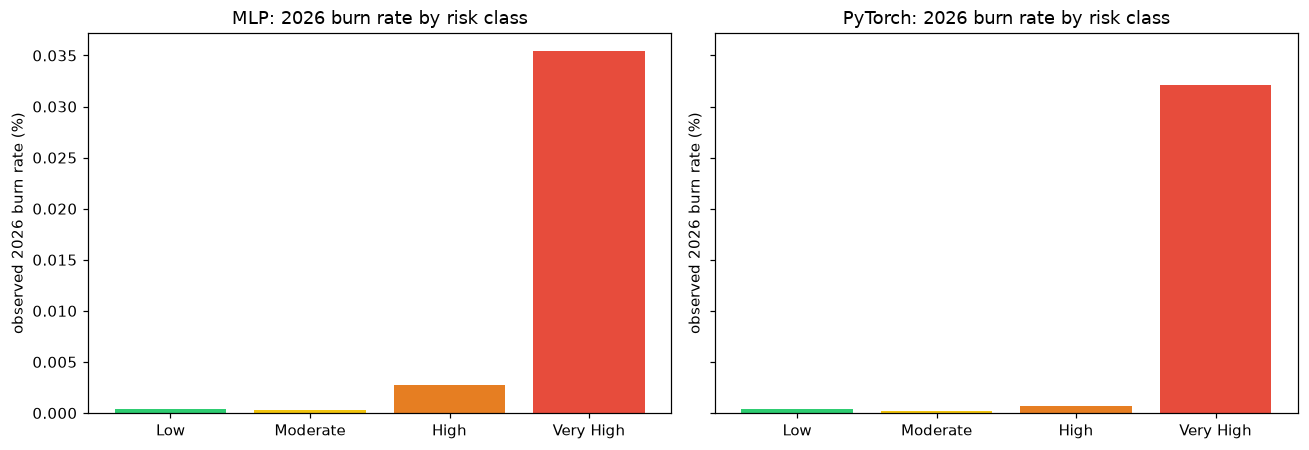

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, mname in zip(axes, [best_sklearn, "PyTorch"]):
    t = risk_burn_table(mname)
    colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"][:len(t)]
    ax.bar(t.index, t["burn_rate"] * 100, color=colors)
    ax.set_title(f"{mname}: 2026 burn rate by risk class")
    ax.set_ylabel("observed 2026 burn rate (%)")
plt.tight_layout(); plt.show()

## 7 · Capture / hit-rate curve
Flag cells from highest risk down; plot the cumulative share of 2026 fires
captured vs the share of area flagged. The further above the diagonal, the better
the map prioritises true fire locations.

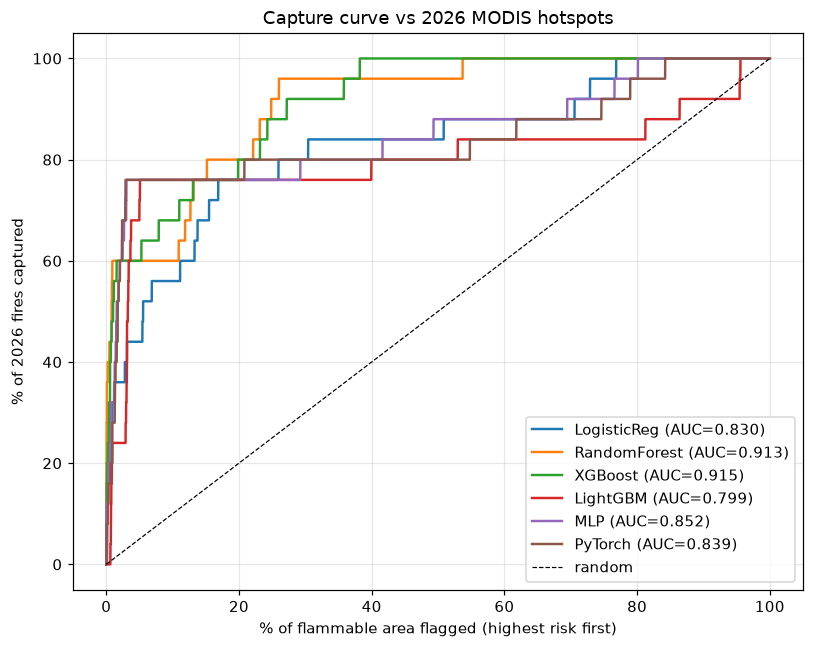

LogisticReg  : top 10% of area captures 56.0% of 2026 fires
LogisticReg  : top 20% of area captures 76.0% of 2026 fires
RandomForest : top 10% of area captures 60.0% of 2026 fires
RandomForest : top 20% of area captures 80.0% of 2026 fires
XGBoost      : top 10% of area captures 68.0% of 2026 fires
XGBoost      : top 20% of area captures 80.0% of 2026 fires
LightGBM     : top 10% of area captures 76.0% of 2026 fires
LightGBM     : top 20% of area captures 76.0% of 2026 fires
MLP          : top 10% of area captures 76.0% of 2026 fires
MLP          : top 20% of area captures 76.0% of 2026 fires
PyTorch      : top 10% of area captures 76.0% of 2026 fires
PyTorch      : top 20% of area captures 76.0% of 2026 fires


In [10]:
def capture_curve(col, label_col="burned_2026"):
    order = np.argsort(-df[col].values)
    y_sorted = df[label_col].values[order]
    cum = np.cumsum(y_sorted) / max(y_sorted.sum(), 1)
    frac = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    return frac, cum

plt.figure(figsize=(7.5, 6))
for name, col in prob_cols.items():
    fa, cf = capture_curve(col)
    auc = (np.trapezoid if hasattr(np, "trapezoid") else np.trapz)(cf, fa)
    plt.plot(fa * 100, cf * 100, lw=1.6, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 100], [0, 100], "k--", lw=0.8, label="random")
plt.xlabel("% of flammable area flagged (highest risk first)")
plt.ylabel("% of 2026 fires captured")
plt.title("Capture curve vs 2026 MODIS hotspots")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

for name, col in prob_cols.items():
    fa, cf = capture_curve(col)
    for pct in (0.10, 0.20):
        idx = int(pct * len(fa)) - 1
        print(f"{name:13s}: top {int(pct*100)}% of area captures {cf[idx]:5.1%} of 2026 fires")

## 8 · Spatial overlay — susceptibility map + 2026 hotspots
Visual sanity check: 2026 fire points should cluster in the bright (high-P) areas.

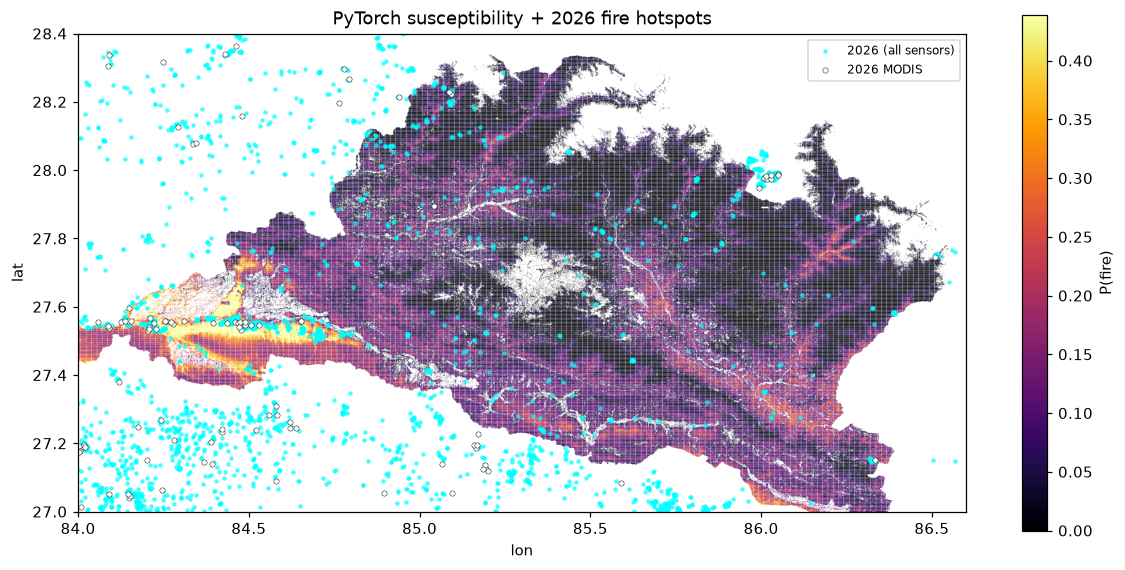

In [11]:
plot_model = "PyTorch"
prob_raster = np.full((H, W), np.nan, dtype="float32")
prob_raster[df["row"].values, df["col"].values] = df[prob_cols[plot_model]].values

plt.figure(figsize=(11, 7))
im = plt.imshow(prob_raster, cmap="inferno", vmin=0,
                vmax=np.nanpercentile(prob_raster, 99),
                extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
plt.colorbar(im, label="P(fire)", shrink=0.7)
plt.scatter(fires_all["lon"], fires_all["lat"], s=4, c="cyan", alpha=0.6, label="2026 (all sensors)")
plt.scatter(fires_modis["lon"], fires_modis["lat"], s=12, c="white",
            edgecolor="black", linewidth=0.3, label="2026 MODIS")
plt.legend(loc="upper right", fontsize=8)
plt.title(f"{plot_model} susceptibility + 2026 fire hotspots")
plt.xlabel("lon"); plt.ylabel("lat"); plt.tight_layout(); plt.show()

## 9 · Side-by-side: PyTorch vs best sklearn (and the rest)

,AUC_PR,AUC_ROC,capture@10%area,%fires_in_High+,top10%_lift
model,,,,,
RandomForest,0.0039,0.9128,0.60,0.96,6.0
XGBoost,0.0010,0.9147,0.68,1.00,6.8
MLP,0.0008,0.8516,0.76,0.76,7.6
PyTorch,0.0004,0.8394,0.76,0.76,7.6
LogisticReg,0.0003,0.8297,0.56,1.00,5.6
LightGBM,0.0001,0.7982,0.76,0.80,7.6


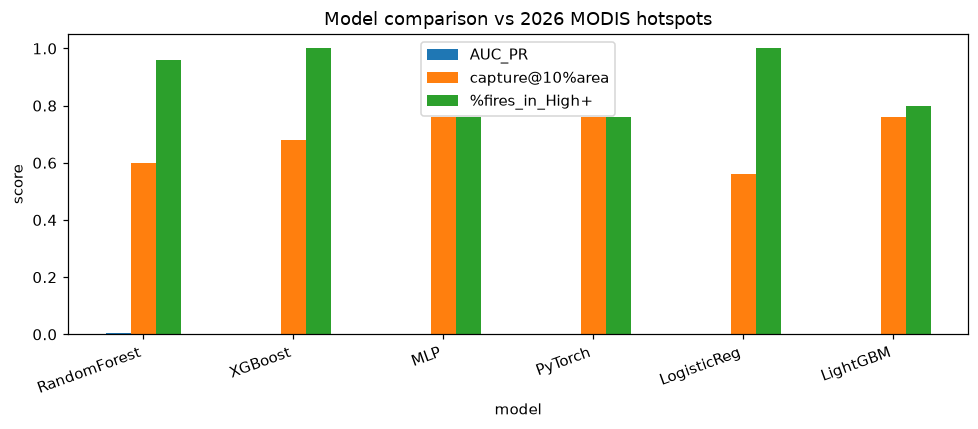

In [12]:
summary = []
for name, col in prob_cols.items():
    y, p = df["burned_2026"].values, df[col].values
    t = risk_burn_table(name)
    hi = t.loc[t.index.isin(["High", "Very High"]), "fires"].sum() / max(t["fires"].sum(), 1)
    fa, cf = capture_curve(col); idx10 = int(0.10 * len(fa)) - 1
    top = np.argsort(-p)[:len(df) // 10]
    lift = df["burned_2026"].values[top].mean() / max(df["burned_2026"].mean(), 1e-12)
    summary.append({"model": name, "AUC_PR": average_precision_score(y, p),
                    "AUC_ROC": roc_auc_score(y, p), "capture@10%area": cf[idx10],
                    "%fires_in_High+": hi, "top10%_lift": lift})
summ = pd.DataFrame(summary).set_index("model").sort_values("AUC_PR", ascending=False)
display(summ.round(4))

ax = summ[["AUC_PR", "capture@10%area", "%fires_in_High+"]].plot(kind="bar", figsize=(9, 4))
ax.set_title("Model comparison vs 2026 MODIS hotspots"); ax.set_ylabel("score")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 10 · Novelty — does it predict *new* fire locations?
Some 2026 fires recur on cells that already burned in 2015–2025. The strongest
test is whether the map ranks **genuinely new** 2026 fire cells (unburned
historically) highly.

In [13]:
new_mask = df[TARGET] == 0
sub = df[new_mask]
print(f"2026 MODIS fires on NEW cells: {int(sub['burned_2026'].sum()):,} / "
      f"{int(df['burned_2026'].sum()):,} total")
print("\nCapture of genuinely-new 2026 fires (cells unburned 2015-2025):")
for name, col in prob_cols.items():
    if sub["burned_2026"].sum() == 0:
        print(f"  {name:13s}: no new fires to score"); continue
    order = np.argsort(-sub[col].values)
    y_sorted = sub["burned_2026"].values[order]
    cum = np.cumsum(y_sorted) / y_sorted.sum()
    idx10 = int(0.10 * len(cum)) - 1
    ap = average_precision_score(sub["burned_2026"].values, sub[col].values)
    print(f"  {name:13s}: AUC-PR={ap:.4f} | top-10%-area captures {cum[idx10]:.1%} of new fires")

2026 MODIS fires on NEW cells: 16 / 25 total

Capture of genuinely-new 2026 fires (cells unburned 2015-2025):
  LogisticReg  : AUC-PR=0.0002 | top-10%-area captures 56.2% of new fires
  RandomForest : AUC-PR=0.0009 | top-10%-area captures 43.8% of new fires
  XGBoost      : AUC-PR=0.0003 | top-10%-area captures 56.2% of new fires
  LightGBM     : AUC-PR=0.0001 | top-10%-area captures 75.0% of new fires
  MLP          : AUC-PR=0.0004 | top-10%-area captures 68.8% of new fires
  PyTorch      : AUC-PR=0.0001 | top-10%-area captures 68.8% of new fires
